In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import root_mean_squared_error as rmse 
from sklearn.metrics import r2_score as r2 

insurance_df = pd.read_csv("insurance.csv")

insurance_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [63]:
insurance_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [64]:
feature = [
    "age",
    "bmi",
]

X = sm.add_constant(insurance_df[feature])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     88.60
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           7.39e-37
Time:                        09:52:59   Log-Likelihood:                -14394.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1335   BIC:                         2.881e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6424.8046   1744.091     -3.684      0.000   -9846.262   -3003.347
age          241.9308     22.298     10.850      0.000     198.187     285.674
bmi          332.9651     51.374      6.481      0.000     232.182     433.748
==============================================================================
Omnibus:                      321.874   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              592.574
Skew:                           1.511   Prob(JB):                    2.11e-129
Kurtosis:                       4.223   Cond. No.                         287.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Metrics

In [65]:
print(f"MAE: {mae(y, model.predict())}")
print(f"RMSE: {rmse(y, model.predict())}")
print(f"R2: {r2(y, model.predict())}")

MAE: 9032.478003391378
RMSE: 11374.110466839007
R2: 0.11718338606939949


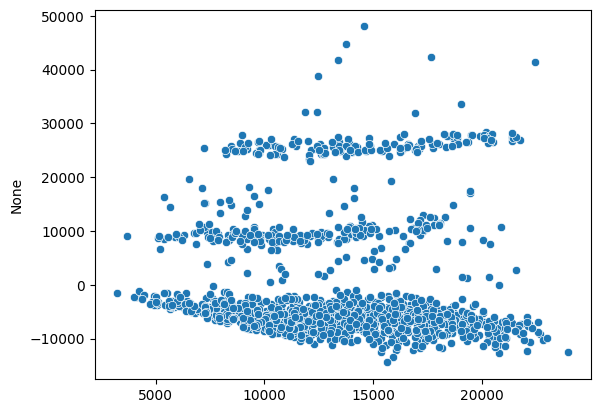

In [66]:
sns.scatterplot(x=model.predict(), y=model.resid);

# Making Predictions

In [67]:
new_data = pd.DataFrame({
    "age": [0, insurance_df["age"].min(), insurance_df["age"].mean(), insurance_df["age"].max()],
    "bmi": [0, insurance_df["bmi"].min(), insurance_df["bmi"].mean(), insurance_df["bmi"].max()],
})

new_data

,age,bmi
0,0.000000,0.000000
1,18.000000,15.960000
2,39.207025,30.663397
3,64.000000,53.130000


In [68]:
X = sm.add_constant(new_data)

model.predict(X)

0    -6424.804612
1     3244.072239
2    13270.422265
3    26749.200448
dtype: float64

In [69]:
insurance_df = insurance_df.assign(
    smoker_flag = np.where(insurance_df["smoker"] == "yes", 1, 0),
    female_flag = np.where(insurance_df["sex"] == "female", 1, 0),
)

X = sm.add_constant(insurance_df[["age", "bmi", "children", "smoker_flag"]])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:52:59   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -1.21e+04    941.984    -12.848      0.000    -1.4e+04   -1.03e+04
age           257.8495     11.896     21.675      0.000     234.512     281.187
bmi           321.8514     27.378     11.756      0.000     268.143     375.559
children      473.5023    137.792      3.436      0.001     203.190     743.814
smoker_flag  2.381e+04    411.220     57.904      0.000     2.3e+04    2.46e+04
==============================================================================
Omnibus:                      301.480   Durbin-Watson:                   2.087
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              722.157
Skew:                           1.215   Prob(JB):                    1.53e-157
Kurtosis:                       5.654   Cond. No.                         292.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

[(-13000.0, 50000.0)]

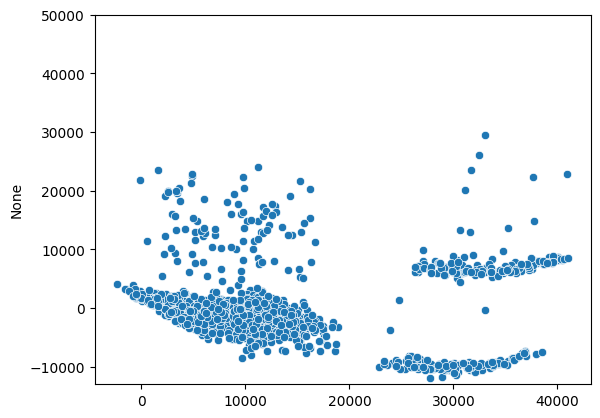

In [70]:
sns.scatterplot(x=model.predict(), y=model.resid).set(ylim=(-13000,50000))